<a href="https://colab.research.google.com/github/YuvrajGaykhe/Netflix_EDA/blob/main/Netflix_EDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("/content/drive/MyDrive/Datasets/netflix_titles.csv")

In [4]:
print(df.head())
print(df.info())
print(df.describe())

  show_id     type                  title         director  \
0      s1    Movie   Dick Johnson Is Dead  Kirsten Johnson   
1      s2  TV Show          Blood & Water              NaN   
2      s3  TV Show              Ganglands  Julien Leclercq   
3      s4  TV Show  Jailbirds New Orleans              NaN   
4      s5  TV Show           Kota Factory              NaN   

                                                cast        country  \
0                                                NaN  United States   
1  Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...   South Africa   
2  Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...            NaN   
3                                                NaN            NaN   
4  Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...          India   

           date_added  release_year rating   duration  \
0  September 25, 2021          2020  PG-13     90 min   
1  September 24, 2021          2021  TV-MA  2 Seasons   
2  September 24, 2021        

In [5]:
df.isnull().sum()

,0
show_id,0
type,0
title,0
director,2634
cast,825
country,831
date_added,10
release_year,0
rating,4
duration,3


In [6]:
df['country'] = df['country'].fillna('Unknown')
df = df.dropna(subset=['date_added'])

In [8]:
df['date_added'] = pd.to_datetime(df['date_added'], format='mixed')
df['year_added'] = df['date_added'].dt.year

In [9]:
df['listed_in'] = df['listed_in'].str.split(',')

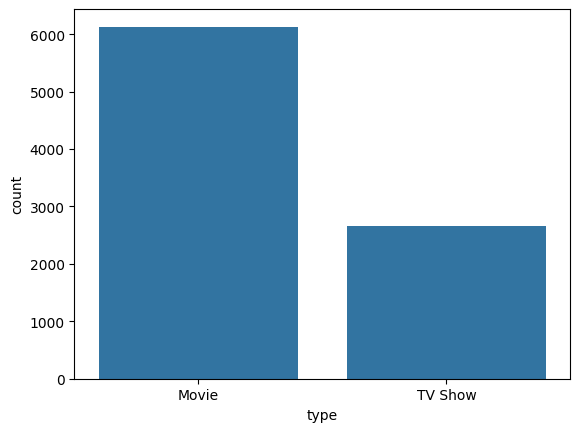

In [10]:
sns.countplot(data=df, x='type')
plt.show()

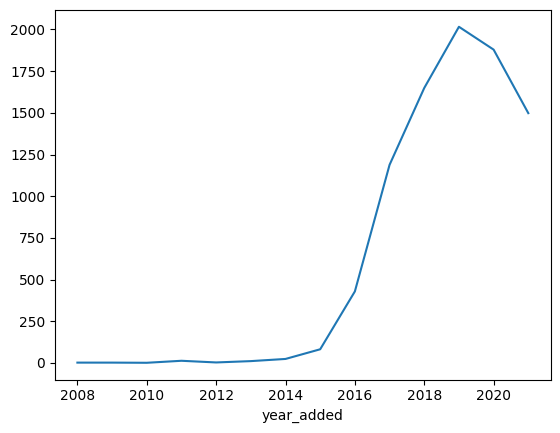

In [11]:
df['year_added'].value_counts().sort_index().plot()
plt.show()

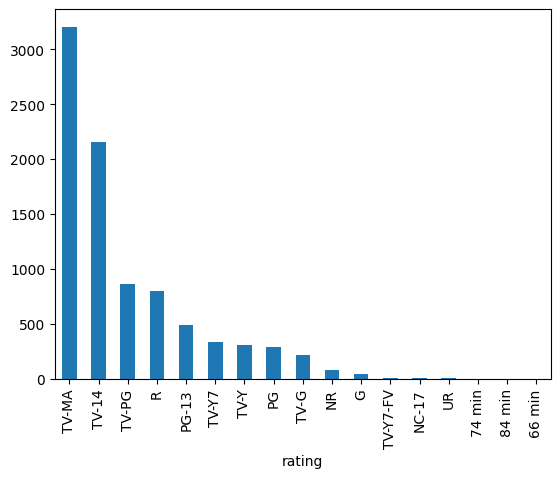

In [12]:
df['rating'].value_counts().plot(kind='bar')
plt.show()

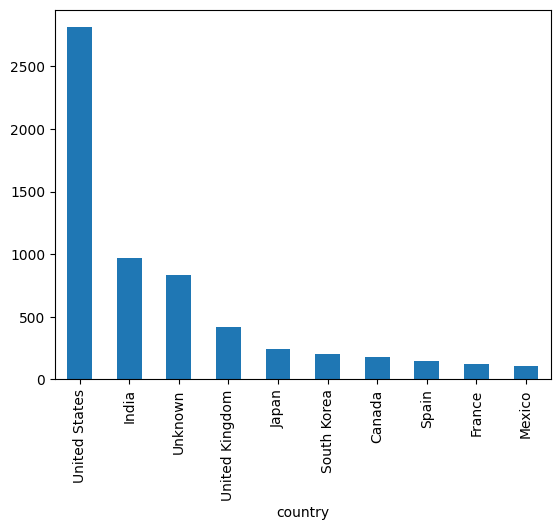

In [13]:
df['country'].value_counts().head(10).plot(kind='bar')
plt.show()

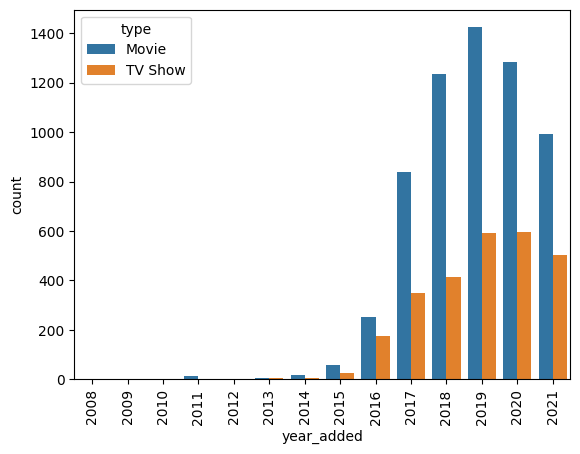

In [14]:
sns.countplot(data=df, x='year_added', hue='type')
plt.xticks(rotation=90)
plt.show()

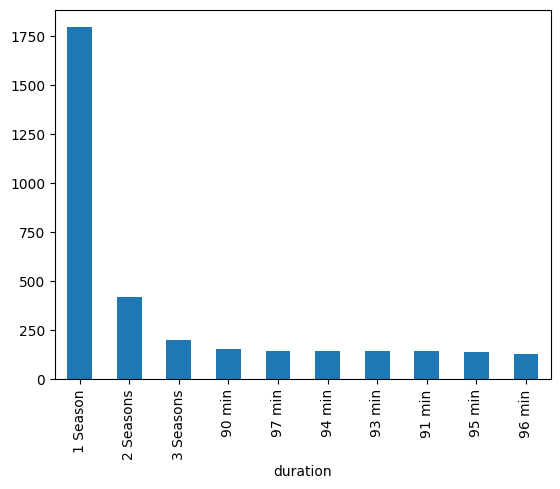

In [15]:
df['duration'].value_counts().head(10).plot(kind='bar')
plt.show()

In [16]:
from collections import Counter

genres = []
for row in df['listed_in']:
    for g in row:
        genres.append(g.strip())

genre_count = Counter(genres)

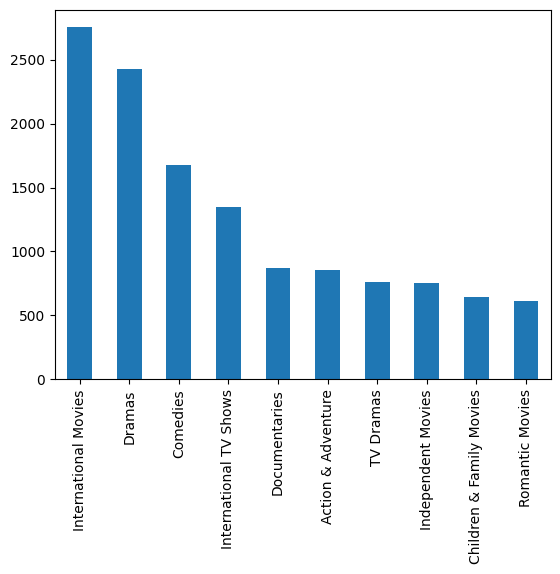

In [17]:
pd.Series(genre_count).sort_values(ascending=False).head(10).plot(kind='bar')
plt.show()